# Lagrange interpolation polynomial

## Theoretical background

In general, when we want to solve a problem, we will have a collection of data at isolated points (for example, the number of people infected with COVID day by day). To work mathematically with those data, we need to define a function from them and then work with that function (for example, differentiate it to understand the trend of the curve, or integrate it to determine the number of affected people, *etc.*). Therefore, being able to create a function that approximates a data set is a fundamental part of a mathematician's practical work. There are several ways to do this. We are now going to look at the simplest of them all: **the Lagrange interpolation polynomial**.

In this case, if we have $n+1$ points, we will build a polynomial of degree $n$ that passes through those points. Think of it as something we have already done at school... but restricted to a particular case: if we are given 2 points, we know (ahem...) how to construct a line (that is, a degree-1 polynomial) passing through those 2 points. Now we are going to learn how to do this for more points.

First we need a theorem guaranteeing the existence of that polynomial:

**Theorem (Lagrange interpolation theorem):**
Given
* $n+1$ distinct points, $x_0,x_1,\ldots,x_n$;
* $n+1$ arbitrary values, $y_0,y_1,\ldots,y_n$;
there exists a unique polynomial $p_n$ of degree {$\leq n$} such that

$$
p_n(x_i)=y_i \, , \quad\forall i=0,1,2,\ldots,n \, .
$$

This polynomial $p_n$ is called the **Lagrange interpolation polynomial at the points $x_0,x_1,\ldots,x_n$
relative to the values $y_0,y_1,\ldots,y_n$**.

In particular, if $y_i=f(x_i)$, we say that **$p_n$ is the Lagrange interpolation polynomial of the
function $f$ at the points $x_i$**.


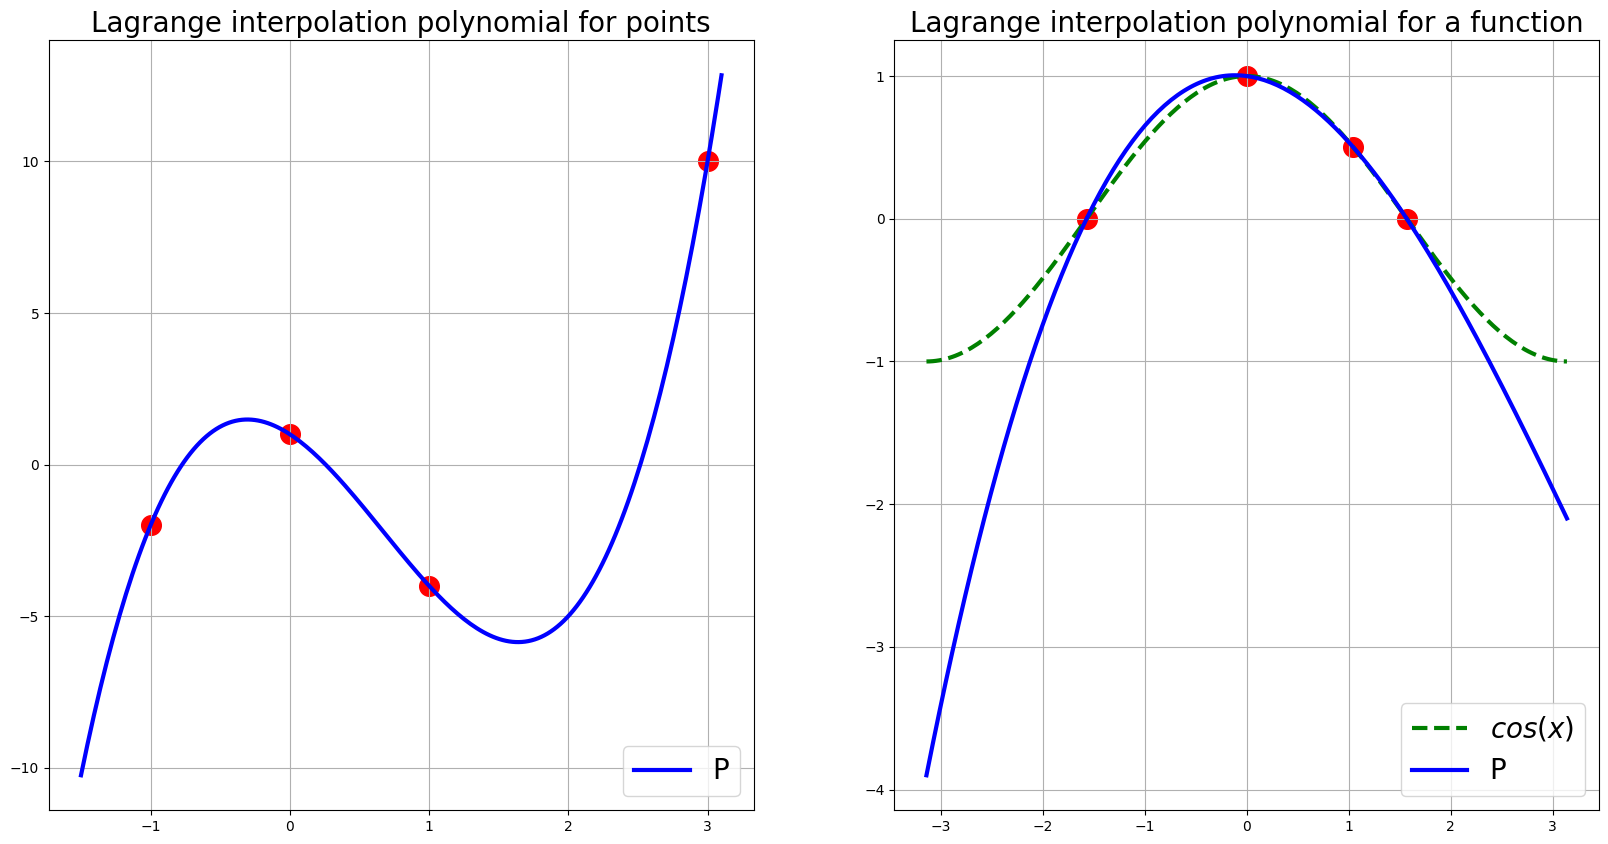

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,10))

# Left figure
ax1 = axs[0]
x_coef = [-1, 0, 1, 3]
y_coef = [-2, 1, -4, 10]
x= np.linspace(-1.5, 3.1, 200)
P_expr = 2*x**3 - 4*x**2 - 3*x + 1

ax1.set_title('Lagrange interpolation polynomial for points', fontsize=20)
ax1.scatter(x_coef, y_coef, s=200, c='r')
ax1.plot(x, P_expr, c='b', ls='-', lw='3', label = 'P')
ax1.grid()
ax1.legend(fontsize=20, loc='lower right')

# Right figure
ax2 = axs[1]
x_coef = [-np.pi/2, 0, np.pi/3, np.pi/2]
y_coef = [0, 1, 0.5, 0]
x= np.linspace(-np.pi, np.pi, 200)
f = np.cos(x)
P_expr = 2/np.pi*(x+np.pi/2)-21/(5*np.pi**2)*(x+np.pi/2)*x+6/(5*np.pi**3)*(x+np.pi/2)*x*(x-np.pi/3)

ax2.set_title('Lagrange interpolation polynomial for a function', fontsize=20)
ax2.scatter(x_coef, y_coef, s=200, c='r')
ax2.plot(x, f, c='g', ls='--', lw='3', label = '$cos(x)$')
ax2.plot(x, P_expr, c='b', ls='-', lw='3', label = 'P')
ax2.grid()
ax2.legend(fontsize=20, loc='lower right')


Once we know that this polynomial exists, the second part comes next: how do we compute it?

There are 2 ways to do this:


## Construction using basis polynomials (Lagrange)

**Definition:**
For each $i=0,1,\ldots,n\,$,
there exists a unique polynomial $l_i$ of degree $\leq n$ such that
* $l_i(x_i)= 1$, and
* $l_i(x_j)=0$, $\forall j\neq i$.

To construct $l_i$, it is immediate to check that

$$
l_i(x)\, = \frac{(x-x_0)(x-x_1)\ldots(x-x_{i-1})(x-x_{i+1})\ldots(x-x_n)}
{(x_i-x_0)(x_i-x_1)\ldots(x_i-x_{i-1})(x_i-x_{i+1})\ldots(x_i-x_n)}.
$$

Now let us think for a moment: $l_i$ is a polynomial of degree $n$ that is equal to 1 at $x_{i}$ and 0 at the remaining nodes, which means that if we multiply it by a real number, for example by $y_i$, then
* $y_i l_i (x_i) = y_i 1 = y_i$,
* $y_i l_i (x_j) = y_i 0 = 0$,

and since the sum of degree-$n$ polynomials is again a degree-$n$ polynomial, the following result is immediate:

**Theorem:**
The Lagrange interpolation polynomial at the nodes $x_0,\, x_1,\ldots,\, x_n$ relative to the values
$y_0,\,y_1,\ldots,\,y_n$ is

$$
p_n(x) \, = \, %\sum_{i=0}^ny_i\,\ell_i(x)=
y_0\,\ell_0(x)+y_1\,\ell_1(x)+\ldots+y_n\,\ell_n(x).
$$


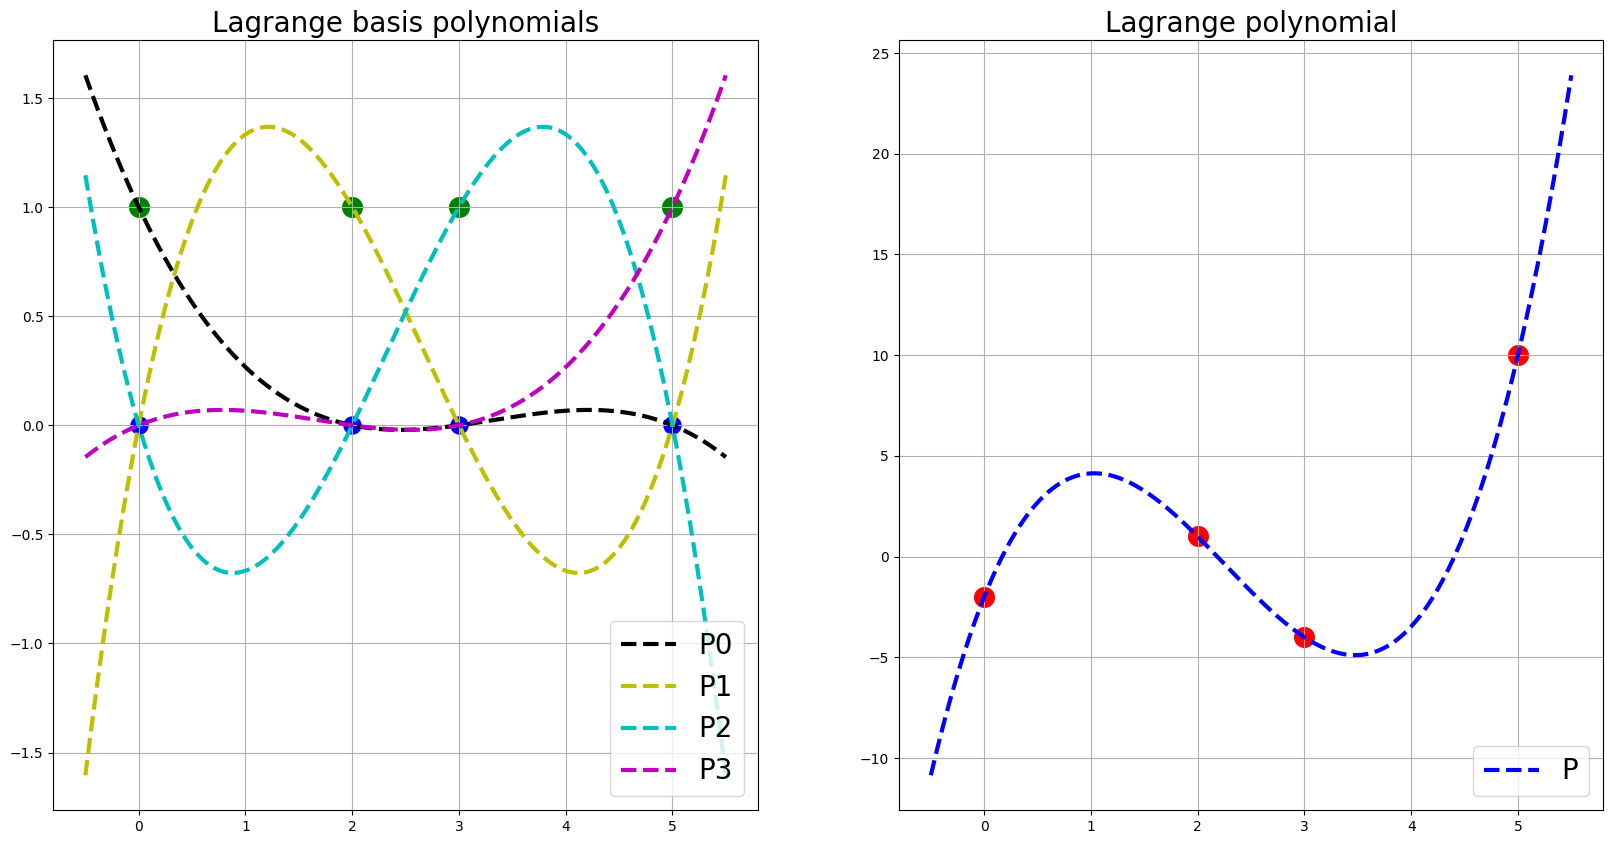

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(20,10))

x = sp.Symbol("x", real = True)

x_coef = [0, 2, 3, 5]
y_coef = [-2, 1, -4, 10]

# We define the expressions of the basis polynomials
P0_expr = ( ((x-x_coef[1])*(x-x_coef[2])*(x-x_coef[3]))
          / ((x_coef[0]-x_coef[1])*(x_coef[0]-x_coef[2])*(x_coef[0]-x_coef[3])) )
P1_expr = ( ((x-x_coef[0])*(x-x_coef[2])*(x-x_coef[3]))
          / ((x_coef[1]-x_coef[0])*(x_coef[1]-x_coef[2])*(x_coef[1]-x_coef[3])) )
P2_expr = ( ((x-x_coef[0])*(x-x_coef[1])*(x-x_coef[3]))
          / ((x_coef[2]-x_coef[0])*(x_coef[2]-x_coef[1])*(x_coef[2]-x_coef[3])) )
P3_expr = ( ((x-x_coef[0])*(x-x_coef[1])*(x-x_coef[2]))
          / ((x_coef[3]-x_coef[0])*(x_coef[3]-x_coef[1])*(x_coef[3]-x_coef[2])) )

# We define the expression of the Lagrange polynomial
P_expr = ( y_coef[0]*P0_expr + y_coef[1]*P1_expr
          + y_coef[2]*P2_expr + y_coef[3]*P3_expr )

# We create `lambdify` functions to plot them
P0 = sp.lambdify(x,P0_expr)
P1 = sp.lambdify(x,P1_expr)
P2 = sp.lambdify(x,P2_expr)
P3 = sp.lambdify(x,P3_expr)

P = sp.lambdify(x,P_expr)

# xx: array that we will use to assign values to the lambdify functions
xx= np.linspace(-0.5, 5.5, 200)

P0_vec = P0(xx)
P1_vec = P1(xx)
P2_vec = P2(xx)
P3_vec = P3(xx)

P_vec = P(xx)

# Left figure
ax1 = axs[0]
ax1.set_title('Lagrange basis polynomials', fontsize=20)

y_ceros = [0, 0, 0, 0] # To plot (xi,0)
ax1.scatter(x_coef, y_ceros, s=150, c='b')
y_unos = [1, 1, 1, 1] # To plot (xi,1)
ax1.scatter(x_coef, y_unos, s=200, c='g')

ax1.plot(xx, P0_vec, c='black', ls='--', lw='3', label = 'P0')
ax1.plot(xx, P1_vec, c='y', ls='--', lw='3', label = 'P1')
ax1.plot(xx, P2_vec, c='c', ls='--', lw='3', label = 'P2')
ax1.plot(xx, P3_vec, c='m', ls='--', lw='3', label = 'P3')
ax1.grid()
ax1.legend(fontsize=20, loc='lower right')

# Right figure
ax2 = axs[1]
ax2.set_title("Lagrange polynomial", fontsize=20)
ax2.scatter(x_coef, y_coef, s=200, c='r')
ax2.plot(xx, P_vec, c='b', ls='--', lw='3', label = 'P')
ax2.grid()
ax2.legend(fontsize=20, loc='lower right')



## Construction using divided differences (Newton)

Constructing the Lagrange polynomial using the basis polynomials, which we have just explained, is easy to understand but difficult to implement in practice. Moreover, if a new datum appears, we must restart the construction from 0.

In general, for practical purposes and especially for programming, it is preferable to construct the Lagrange polynomial using the table of divided differences, as we explain below.

Before anything else, we should remember that the Lagrange polynomial is unique and, therefore, the result must be the same regardless of which method is used.

* Divided differences of order 0:

    $$
    [y_i] \, =\, y_i \, ,\quad \forall i=0,1,\ldots,n\, .
    $$

* Divided differences of order $k$:

    $$
    [y_i,y_{i+1},\ldots,y_{i+k}] =
    \displaystyle\frac{[y_i,y_{i+1},...,y_{i+k-1}]-[y_{i+1},...,y_{i+k}]}{x_i-x_{i+k}} , \, \forall
    i=0,1,...,n-k \, .
    $$


In practice, the computation of divided differences is arranged in a table:

$
\begin{array}{c|ccccc}
x_0 & {\color{red} y_0}  & {\color{red} [y_0 , y_1]} & {\color{red} [y_0 , y_1 , y_2]}  &  \ldots & {\color{red} [y_0,y_1,\ldots,y_n]}  \\[1ex]
x_1 & y_1  & [y_1 , y_2]  & [y_1 , y_2 , y_3] & \ldots &  \\[1ex]
x_2 & y_2  & [y_2 , y_3]  & [y_2 , y_3 , y_4] & \ldots &  \\[1ex]
\ldots & \ldots & \ldots & \ldots & \ldots &  \\[1ex]
x_{n-1} & y_{n-1}  & [y_{n-1} , y_n]  &  &  &  \\[1ex]
x_n & y_n
\end{array}
$

Here we are interested in the first row of the resulting matrix (in red).

**Newton's formula:**
The Lagrange interpolation polynomial at the points $x_0,\, x_1,\ldots,\, x_n \, $ relative to the values $y_0,\,y_1,\ldots,\,y_n\,$ can be written as

$$
\begin{array}{lcl}
p_n(x)\, &=& [y_0] \, +\, [y_0,y_1]\, (x-x_0) \, +\, [y_0,y_1,y_2]\, (x-x_0)(x-x_1) \, +  \\
         & & \ldots +\, [y_0,y_1,\ldots,y_n]\, (x-x_0)(x-x_1)\ldots(x-x_{n-1}).
\end{array}
$$

**Note:**
After constructing the table, an additional datum can be added by taking advantage of the calculations already performed.


We are going to make our own **Numpy** version of the computation of the Lagrange interpolation polynomial using the table of divided differences.

This will be the first time we use a `function`. In this case it is (almost) unavoidable, since in principle we do not know the number of points that we will take as data. Therefore, if we want our program to work in all cases, we need an accumulating loop for the summation in Newton's formula.


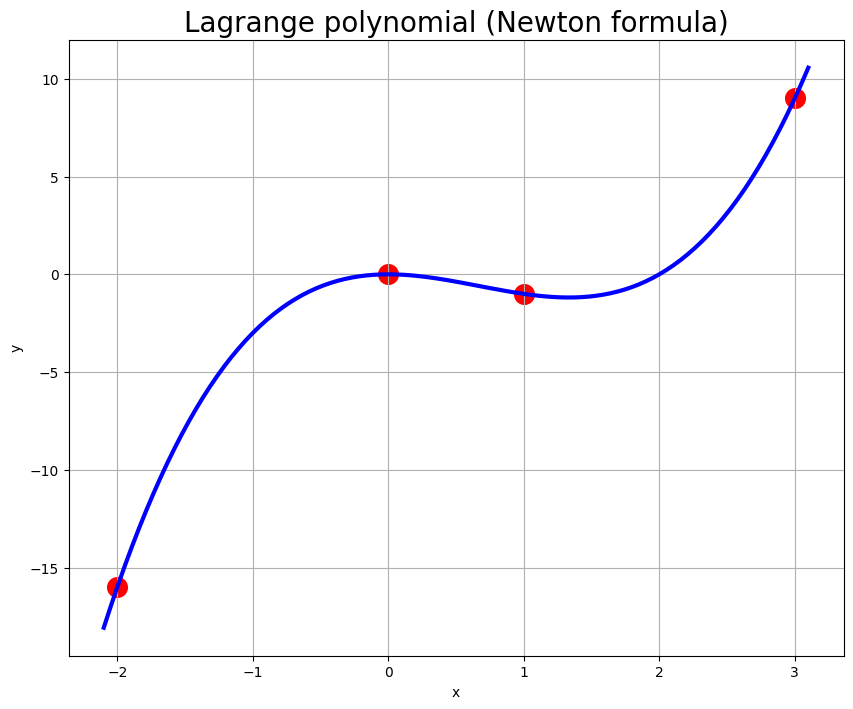

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.Symbol("x", real = True)

x_coef = [-2, 0, 1, 3]
y_coef = [-16, 0, -1, 9]

n = len(x_coef)

# We store the divided-difference matrix in "tabla"
tabla = np.zeros([n, n])

# The first column will contain the y-data
tabla[:,0] = y_coef

# We need a double loop to create the rest of "tabla"
for j in range(1,n):
    for i in range(n-j):
        tabla[i,j] = (tabla[i+1,j-1] - tabla[i,j-1]) / (x_coef[i+j]-x_coef[i])

# We define the expression for the Lagrange polynomial (Newton version)
P_expr = tabla[0,0]
multiplica = 1
for k in range(1,n):
    multiplica = multiplica * (x - x_coef[k-1])
    P_expr = P_expr + tabla[0,k] * multiplica

# We create the lambdify function to plot it
P = sp.lambdify(x,P_expr)

xx = np.linspace(-2.1, 3.1, 200)
P_vec = P(xx)

# We plot the result
fig = plt.figure(figsize = (10,8))
plt.scatter(x_coef, y_coef, s=200, c='r')
plt.plot(xx, P_vec, 'b', lw='3')
plt.title('Lagrange polynomial (Newton formula)', fontsize=20)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


**Note:**

There is a Python library, **SciPy**, in which quite a few numerical methods are already pre-programmed (well, actually a great many), including, of course, the Lagrange polynomial.
Although in this course we will not use SciPy (**which means that we will NOT accept it as correct in your practical assignments**), we include its use below in case it may be useful to you in the future:


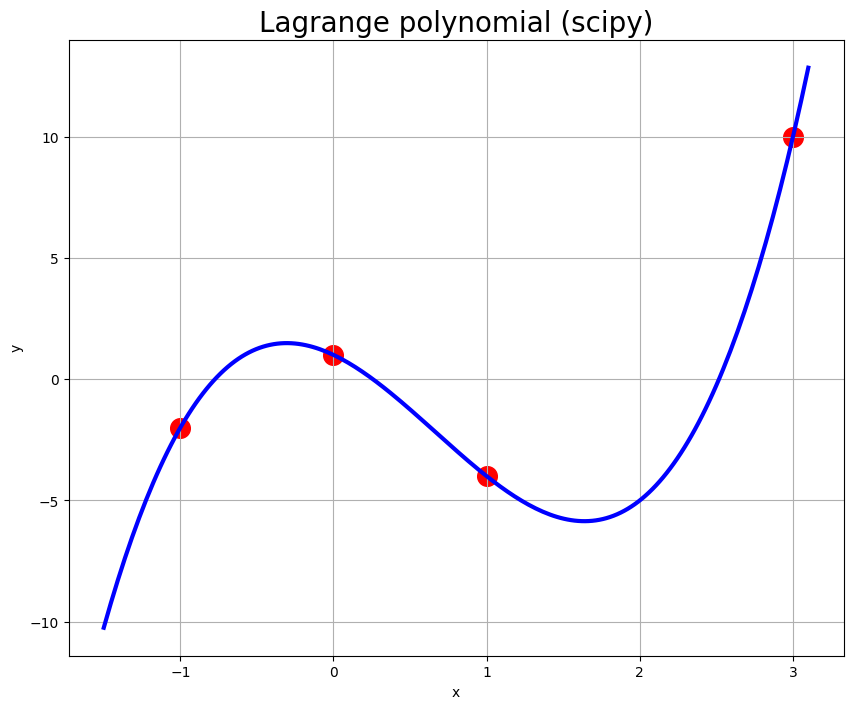

In [4]:
from scipy.interpolate import lagrange

x_coef = [-1, 0, 1, 3]
y_coef = [-2, 1, -4, 10]
x= np.linspace(-1.5, 3.1, 200)

pol_lag = lagrange(x_coef, y_coef)

fig = plt.figure(figsize = (10,8))
plt.scatter(x_coef, y_coef, s=200, c='r')
plt.plot(x, pol_lag(x), 'b', lw='3')
plt.title('Lagrange polynomial (scipy)', fontsize=20)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Links for further reading

Here are some links, in case you would like to take a look:
* [Page on Lagrange construction in *Python Numerical Methods*, Berkeley.](https://pythonnumericalmethods.berkeley.edu/notebooks/chapter17.04-Lagrange-Polynomial-Interpolation.html)
* [Page on Newton construction in *Python Numerical Methods*, Berkeley.](https://pythonnumericalmethods.berkeley.edu/notebooks/chapter17.05-Newtons-Polynomial-Interpolation.html)
* [Wikipedia entry, Lagrange construction.](https://es.wikipedia.org/wiki/Interpolaci%C3%B3n_polin%C3%B3mica_de_Lagrange#:~:text=En%20an%C3%A1lisis%20num%C3%A9rico%2C%20el%20polinomio,por%20Leonhard%20Euler%20en%201783.)
* [Wikipedia entry, Newton construction.](https://es.wikipedia.org/wiki/Interpolaci%C3%B3n_polin%C3%B3mica_de_Newton)


## Exercises for you to do

**Exercise 1:**

Prepare a program to evaluate and plot the Lagrange polynomial, constructed by means of the basis monomials, using a function.


In [5]:
# WRITE YOUR CODE HERE


**Exercise 2:**

Construct a Lagrange polynomial, using the table of divided differences, to interpolate the function $\sin(x)$ at the points $\frac{\pi}{2}, \; 0, \; \frac{\pi}{3}, \; \frac{\pi}{2}$.


In [6]:
# WRITE YOUR CODE HERE


## Exercises for a little more practice

To practice a little more on what we have just explained, we suggest that you do the following exercises (with the help of Python, if you wish):

* https://existelimite.blogspot.com/2014/02/calculo-del-polinomio-de-interpolacion.html
* https://existelimite.blogspot.com/2016/11/aproximamos-la-funcion-seno-con-un.html
